# Download Dependencias   QLoRA

In [ ]:
!pip install --no-deps bitsandbytes accelerate xformers peft trl==0.22.2 triton

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.8/544.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 123.7 MB/s eta 0:00:00


In [ ]:
!pip install --no-deps cut_cross_entropy unsloth_zoo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.9 MB/s eta 0:00:00


In [ ]:
!pip install sentencepiece protobuf "datasets>=3.4.1" huggingface_hub hf_transfer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 62.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.7.4 requires msgspec, which is not installed.
unsloth-zoo 2026.7.4 requires tyro; sys_platform != "darwin" or platform_machine != "arm64", which is not installed.
unsloth-zoo 2026.7.4 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 4.0.0 which is incompatible.
unsloth-zoo 2026.7.4 requires torchao>=0.13.0; sys_platform != "darwin" or platform_machine != "arm64", but you have torchao 0.10.0 which is incompatible.
unsloth-zoo 2026.7.4 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!=4.54.0,!=4.55.0,!=4.55.1,!=4.57.4,!=4.57.5,!=5.0.0,!=5.1.0,<=5.5.0,>=4.51.3, but you have transformers 5.13.1 which is incompatible.


In [ ]:
!pip install "transformers==4.56.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 119.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 63.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.7.4 requires msgspec, which is not installed.
unsloth-zoo 2026.7.4 requires tyro; sys_platform != "darwin" or platform_machine != "arm64", which is not installed.
unsloth-zoo 2026.7.4 requires data

In [ ]:
!pip install --no-deps unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 MB 42.2 MB/s eta 0:00:00


In [ ]:
import shutil

## Imports (unsloth MUST come first, before trl/transformers/peft)

importing trl before unsloth is what caused the <EOS_TOKEN> patching bug. unsloth first is the documented fix.


In [ ]:
import unsloth
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
import gc
import json
import shutil
import time
from pathlib import Path

In [ ]:
import torch
from PIL import Image
from datasets import Dataset
from trl import SFTConfig, SFTTrainer
from transformers import TrainerCallback


In [ ]:
import os
import psutil

In [ ]:
print(os.cpu_count())

48


Mount Google Drive for checkpoint save

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


Check Hardware

In [ ]:
if torch.cuda.is_available():
    print(f"CUDA is available! Number of GPUs: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    print(f"Current CUDA device: {torch.cuda.current_device()}")
else:
    print("CUDA is not available on this system.")

CUDA is available! Number of GPUs: 1
  GPU 0: NVIDIA RTX PRO 6000 Blackwell Server Edition
Current CUDA device: 0


In [ ]:
# System RAM
sys_ram = psutil.virtual_memory().total / (1024**3) # Convert bytes to GB
print(f"System RAM: {sys_ram:.2f} GB")

# CPU Cores
cpu_cores = psutil.cpu_count(logical=False) # Physical cores
print(f"CPU Physical Cores: {cpu_cores}")
cpu_logical_cores = psutil.cpu_count(logical=True) # Logical cores (includes hyperthreading)
print(f"CPU Logical Cores: {cpu_logical_cores}")

# GPU RAM (from torch)
if torch.cuda.is_available():
    gpu_ram_bytes = torch.cuda.get_device_properties(0).total_memory
    gpu_ram_gb = gpu_ram_bytes / (1024**3) # Convert bytes to GB
    print(f"GPU RAM: {gpu_ram_gb:.2f} GB")
else:
    print("CUDA is not available, cannot retrieve GPU RAM.")

System RAM: 176.88 GB
CPU Physical Cores: 24
CPU Logical Cores: 48
GPU RAM: 94.97 GB


In [ ]:
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}")
    print(f"VRAM: {props.total_memory / 1e9:.1f} GB")
print(f"bf16 supported: {unsloth.is_bfloat16_supported()}")

CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB
bf16 supported: True


Paths and hyperparameters  
Project Soure of Thruth

In [ ]:
DRIVE_ARCHIVE = Path("/content/drive/MyDrive/aegis_art_atelier/archives/Aegis-Art-Atelier-22K.tar.gz")
DRIVE_SPLITS_DIR = Path("/content/drive/MyDrive/aegis_art_atelier/splits")

In [ ]:
LOCAL_ROOT = Path("/content")
LOCAL_DATASET_DIR = LOCAL_ROOT / "Aegis-Art-Atelier-22K"
SANITY_CHECK_SAMPLES_PER_SPLIT = 5
SANITY_CHECK_SEED = 42

# Extract the dataset archive
!mkdir -p "{LOCAL_ROOT}"
!tar -xzf "{DRIVE_ARCHIVE}" -C "{LOCAL_ROOT}"

print(f"Extracted data to: {LOCAL_DATASET_DIR}")

Extracted data to: /content/Aegis-Art-Atelier-22K


In [ ]:
archive_size_gb = DRIVE_ARCHIVE.stat().st_size / (1024 ** 3)
print(f"\nA files : {DRIVE_ARCHIVE.name} ({archive_size_gb:.2f} GB)")



A files : Aegis-Art-Atelier-22K.tar.gz (3.80 GB)


In [ ]:
assert LOCAL_DATASET_DIR.exists(), (
    f" failed  folder: {LOCAL_DATASET_DIR}. "
    "check the  file  tar.gz."
)
print("OK.")

OK.


Checkpoints and outputs go to LOCAL disk during training

In [ ]:
for split_name in ("train", "val", "test"):
    source = DRIVE_SPLITS_DIR / f"{split_name}_manifest.jsonl"
    destination = LOCAL_DATASET_DIR / f"{split_name}_manifest.jsonl"
    shutil.copy2(source, destination)
    print(f"Copiado: {source.name} -> {destination}")

Copiado: train_manifest.jsonl -> /content/Aegis-Art-Atelier-22K/train_manifest.jsonl
Copiado: val_manifest.jsonl -> /content/Aegis-Art-Atelier-22K/val_manifest.jsonl
Copiado: test_manifest.jsonl -> /content/Aegis-Art-Atelier-22K/test_manifest.jsonl


In [ ]:
# %% Cell 3 - Paths and hyperparameters (single source of truth)

Final artifacts are copied here ONCE, at the very end.

In [ ]:
LOCAL_DATASET_DIR = Path("/content/Aegis-Art-Atelier-22K")
TRAIN_MANIFEST = LOCAL_DATASET_DIR / "train_manifest.jsonl"
VAL_MANIFEST = LOCAL_DATASET_DIR / "val_manifest.jsonl"

In [ ]:
# Checkpoints and outputs go to LOCAL disk during training (post-mortem RC1).
LOCAL_OUTPUT_DIR = Path("/content/aegis_art_atelier_checkpoints")

In [ ]:
# Final artifacts are copied here ONCE, at the very end.
DRIVE_OUTPUT_DIR = Path("/content/drive/MyDrive/aegis_art_atelier/model")

In [ ]:
MODEL_NAME = "unsloth/Qwen2.5-VL-7B-Instruct-unsloth-bnb-4bit"

In [ ]:
INSTRUCTION_TEXT = "Describe this artwork in detail: subject, style, composition, and mood."

##  Benchmarked configuration. hyperparameters


In [ ]:
# Benchmarked configuration.
PER_DEVICE_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4
NUM_EPOCHS = 3
LEARNING_RATE = 2e-4
LORA_R = 32
LORA_ALPHA = 32
MAX_SEQ_LENGTH = 2048

In [ ]:

EVAL_SUBSET_SIZE = 300     # subsample of val, trend indicator not microscope
EVAL_STEPS = 500
SAVE_STEPS = 500
SAVE_TOTAL_LIMIT = 2
LOGGING_STEPS = 20
WARMUP_RATIO = 0.05

Load manifests (metadata only, images stay on disk)

In [ ]:

def load_manifest(path: Path) -> list[dict]:
    records = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


## Check ataset size before setting fine tuning

In [ ]:
train_records = load_manifest(TRAIN_MANIFEST)
val_records_full = load_manifest(VAL_MANIFEST)

In [ ]:
# Subsample the eval set once, deterministically (post-mortem RC2).
val_records = val_records_full[:EVAL_SUBSET_SIZE]

In [ ]:
print(f"Train records: {len(train_records)}")
print(f"Val records (full): {len(val_records_full)}")
print(f"Val records (subsampled for eval): {len(val_records)}")


Train records: 18919
Val records (full): 2672
Val records (subsampled for eval): 300


## Build lazy datasets

 Key point (Unsloth issue #2315): do NOT materialize all images into a list.

 We store only lightweight metadata rows, and open each JPEG from disk inside
a transform that runs on-demand when the collator requests a sample. This
 keeps RAM flat regardless of dataset size.

In [ ]:

def build_metadata_dataset(records: list[dict]) -> Dataset:
    rows = {
        "image_path": [str(LOCAL_DATASET_DIR / r["image_path"]) for r in records],
        "caption": [r["caption_clean"] for r in records],
    }
    return Dataset.from_dict(rows)


Important lazy Load for training speed and VRAM Work Resoruces

In [ ]:
def make_lazy_transform():
    """Return a transform that opens images from disk on access, not upfront."""
    def transform(batch: dict) -> dict:
        messages_batch = []
        for image_path, caption in zip(batch["image_path"], batch["caption"]):
            image = Image.open(image_path).convert("RGB")
            messages_batch.append(
                [
                    {
                        "role": "user",
                        "content": [
                            {"type": "text", "text": INSTRUCTION_TEXT},
                            {"type": "image", "image": image},
                        ],
                    },
                    {
                        "role": "assistant",
                        "content": [{"type": "text", "text": caption}],
                    },
                ]
            )
        return {"messages": messages_batch}

    return transform


Getting started

In [ ]:
train_dataset = build_metadata_dataset(train_records)
train_dataset = train_dataset.with_transform(make_lazy_transform())

In [ ]:
eval_dataset = build_metadata_dataset(val_records)
eval_dataset = eval_dataset.with_transform(make_lazy_transform())

In [ ]:
print("Lazy datasets ready (images open on access, not held in RAM).")


Lazy datasets ready (images open on access, not held in RAM).


##  Load the model and attach the LoRA adapter

In [ ]:
# %% Cell 6 - Load the model and attach the LoRA adapter
model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_NAME,
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
    max_seq_length=MAX_SEQ_LENGTH,
)


==((====))==  Unsloth 2026.7.4: Fast Qwen2_5_Vl patching. Transformers: 4.56.2.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=False,      # vision encoder frozen
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0,
    bias="none",
    random_state=3407,
)

In [ ]:
FastVisionModel.for_training(model)
print("Model loaded and LoRA adapter attached.")


Model loaded and LoRA adapter attached.


Loss history callback (for plotting train/eval loss at the end)

In [ ]:

class LossHistoryCallback(TrainerCallback):
    """Collects train and eval loss over steps for later plotting."""

    def __init__(self):
        self.train_history = []   # list of (step, loss)
        self.eval_history = []    # list of (step, loss)

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        step = state.global_step
        if "loss" in logs:
            self.train_history.append((step, logs["loss"]))
        if "eval_loss" in logs:
            self.eval_history.append((step, logs["eval_loss"]))


In [ ]:
loss_history = LossHistoryCallback()


## Training configuration

In [ ]:
# %% Cell 8 - Training configuration
training_args = SFTConfig(
    output_dir=str(LOCAL_OUTPUT_DIR),      # LOCAL disk, never Drive during run
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=NUM_EPOCHS,
    #max_steps =10,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="linear",
    bf16=True,
    optim="adamw_8bit",
    weight_decay=0.01,

    # Evaluation: infrequent, subsampled (post-mortem RC2).
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,

    # Checkpointing: local, capped, keep the best (post-mortem RC1 + safety net).
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    logging_steps=LOGGING_STEPS,
    report_to="none",

    # Vision-specific data handling.
    remove_unused_columns=False,
    dataset_text_field="",
    dataset_kwargs={"skip_prepare_dataset": True},

    # Feed the GPU from CPU workers (post-mortem VLM addition 2).
    dataloader_num_workers=16,
    dataloader_pin_memory=True,
)

In [ ]:
# %% Cell 9 - Build the trainer
trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,               # required in TRL 0.22 for Qwen VL
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=training_args,
    callbacks=[loss_history],
)


Unsloth: Model does not have a default image size - using 512


Important Image size checkup.  

896x896 = 802,816 pixels. Check if max_pixels is below that.

In [ ]:
# Diagnostic: inspect the processor's pixel budget
processor = tokenizer  # in Qwen2.5-VL, "tokenizer" is the full processor
image_processor = processor.image_processor
print("min_pixels:", getattr(image_processor, "min_pixels", "not set"))
print("max_pixels:", getattr(image_processor, "max_pixels", "not set"))

print("\n896x896 = 802816 pixels")
print("If max_pixels < 802816, your images are being downscaled at tokenization.")

min_pixels: 3136
max_pixels: 12845056

896x896 = 802816 pixels
If max_pixels < 802816, your images are being downscaled at tokenization.


In [ ]:
steps_per_epoch = len(train_records) // (PER_DEVICE_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total steps ({NUM_EPOCHS} epochs): {steps_per_epoch * NUM_EPOCHS}")


Steps per epoch: 1182
Total steps (3 epochs): 3546


"" Main Training Loop

In [ ]:
 gc.collect()
torch.cuda.empty_cache()
start_time = time.monotonic()
trainer.train()
elapsed_hours = (time.monotonic() - start_time) / 3600

print(f"\nTraining finished in {elapsed_hours:.2f} hours.")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 18,919 | Num Epochs = 3 | Total steps = 3,549
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 80,740,352 of 8,372,907,008 (0.96% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
500,0.995900,0.973281
1000,0.912600,0.929635
1500,0.851600,0.911527
2000,0.845600,0.893624
2500,0.754200,0.894999
3000,0.755000,0.887767
3500,0.723700,0.882219


Unsloth: Not an error, but Qwen2_5_VLForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient



Training finished in 3.01 hours.


 Plot training and eval loss

In [ ]:
# %% Cell 11 - Plot training and eval loss
import matplotlib.pyplot as plt

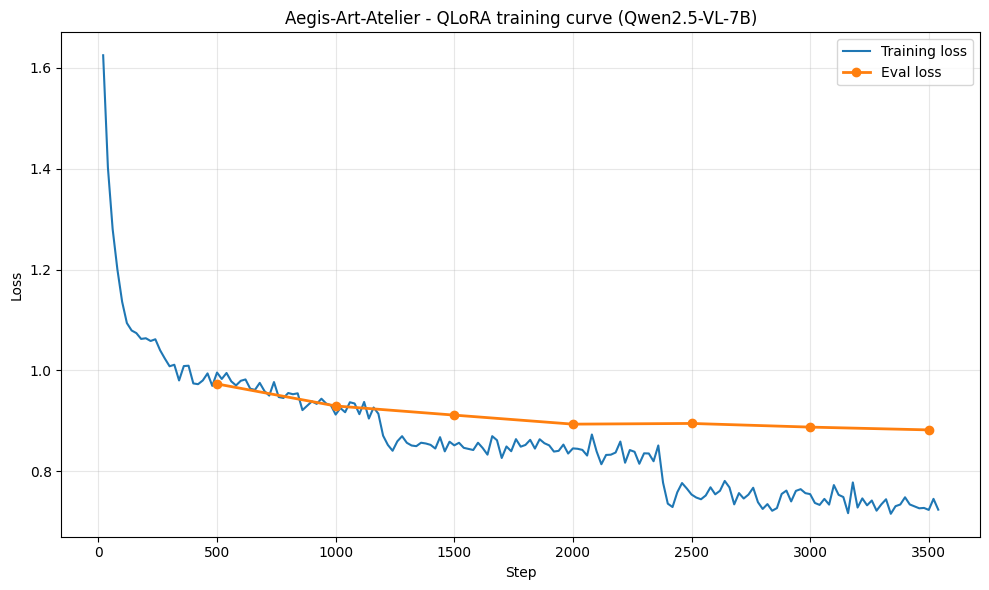

Loss curve saved.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

if loss_history.train_history:
    train_steps, train_losses = zip(*loss_history.train_history)
    ax.plot(train_steps, train_losses, label="Training loss", linewidth=1.5)

if loss_history.eval_history:
    eval_steps, eval_losses = zip(*loss_history.eval_history)
    ax.plot(eval_steps, eval_losses, label="Eval loss", marker="o", linewidth=2)

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Aegis-Art-Atelier - QLoRA training curve (Qwen2.5-VL-7B)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(LOCAL_OUTPUT_DIR / "loss_curve.png"), dpi=150)
plt.show()

print("Loss curve saved.")

Traning and Val Loss Curves Shows the Fine-Tuning comes into **Plateau** More epochs wont help,  it mught learn trianing set questions and answer by hearth , so it was good to stopped it at epoch 3.

In [ ]:
# %% Cell 12 - Save the best adapter locally, then copy to Drive ONCE
# load_best_model_at_end already restored the best checkpoint into `model`.
FINAL_LOCAL_DIR = LOCAL_OUTPUT_DIR / "final_adapter"
model.save_pretrained(str(FINAL_LOCAL_DIR))
tokenizer.save_pretrained(str(FINAL_LOCAL_DIR))
print(f"Best adapter saved locally: {FINAL_LOCAL_DIR}")


Best adapter saved locally: /content/aegis_art_atelier_checkpoints/final_adapter


## Single copy to Drive at the very end (post-mortem RC1).

In [ ]:

DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
drive_final = DRIVE_OUTPUT_DIR / "final_adapter"
if drive_final.exists():
    shutil.rmtree(drive_final)
shutil.copytree(FINAL_LOCAL_DIR, drive_final)

PosixPath('/content/drive/MyDrive/aegis_art_atelier/model/final_adapter')

Check Artifacts  ware to be saved on my drive directory

In [ ]:
!ls -la /content/aegis_art_atelier_checkpoints/final_adapter
!echo "---"
!ls -la /content/drive/MyDrive/aegis_art_atelier/model/final_adapter

total 331008
drwxr-xr-x 2 root root      4096 Jul 20 23:21 .
drwxr-xr-x 5 root root      4096 Jul 20 23:21 ..
-rw-r--r-- 1 root root      1525 Jul 20 23:21 adapter_config.json
-rw------- 1 root root 323020048 Jul 20 23:21 adapter_model.safetensors
-rw-r--r-- 1 root root       605 Jul 20 23:21 added_tokens.json
-rw-r--r-- 1 root root      1017 Jul 20 23:21 chat_template.jinja
-rw-r--r-- 1 root root   1671853 Jul 20 23:21 merges.txt
-rw-r--r-- 1 root root       791 Jul 20 23:21 preprocessor_config.json
-rw-r--r-- 1 root root      5270 Jul 20 23:21 README.md
-rw-r--r-- 1 root root       614 Jul 20 23:21 special_tokens_map.json
-rw-r--r-- 1 root root      4757 Jul 20 23:21 tokenizer_config.json
-rw-r--r-- 1 root root  11421896 Jul 20 23:21 tokenizer.json
-rw-r--r-- 1 root root       935 Jul 20 23:21 video_preprocessor_config.json
-rw-r--r-- 1 root root   2776833 Jul 20 23:21 vocab.json
---
total 330966
-rw------- 1 root root      1525 Jul 20 23:21 adapter_config.json
-rw------- 1 root root

Double check weights has been save, !important before shutting down notebook

In [ ]:
!ls -lh /content/drive/MyDrive/aegis_art_atelier/model/final_adapter

total 324M
-rw------- 1 root root 1.5K Jul 20 23:21 adapter_config.json
-rw------- 1 root root 309M Jul 20 23:21 adapter_model.safetensors
-rw------- 1 root root  605 Jul 20 23:21 added_tokens.json
-rw------- 1 root root 1017 Jul 20 23:21 chat_template.jinja
-rw------- 1 root root 1.6M Jul 20 23:21 merges.txt
-rw------- 1 root root  791 Jul 20 23:21 preprocessor_config.json
-rw------- 1 root root 5.2K Jul 20 23:21 README.md
-rw------- 1 root root  614 Jul 20 23:21 special_tokens_map.json
-rw------- 1 root root 4.7K Jul 20 23:21 tokenizer_config.json
-rw------- 1 root root  11M Jul 20 23:21 tokenizer.json
-rw------- 1 root root  935 Jul 20 23:21 video_preprocessor_config.json
-rw------- 1 root root 2.7M Jul 20 23:21 vocab.json


In [ ]:
# Also copy the loss curve for the record.
loss_curve_src = LOCAL_OUTPUT_DIR / "loss_curve.png"
if loss_curve_src.exists():
    shutil.copy2(loss_curve_src, DRIVE_OUTPUT_DIR / "loss_curve.png")

##  Perform Test Set Eval()

In [ ]:
TEST_MANIFEST = LOCAL_DATASET_DIR / "test_manifest.jsonl"
test_records = load_manifest(TEST_MANIFEST)
print(f"Test records: {len(test_records)}")

Test records: 667


In [ ]:
test_dataset = build_metadata_dataset(test_records)
test_dataset = test_dataset.with_transform(make_lazy_transform())


Even tohugh  the test Loss was ~ 0.9 , we do not deem the fine tuning as failure.  it was expected for this type of datasets

In [ ]:
test_metrics = trainer.evaluate(eval_dataset=test_dataset, metric_key_prefix="test")

In [ ]:
print("\nTest set metrics (best checkpoint, per load_best_model_at_end):")
for key, value in test_metrics.items():
    print(f"  {key}: {value}")



Test set metrics (best checkpoint, per load_best_model_at_end):
  test_loss: 0.9027114510536194
  test_runtime: 52.9833
  test_samples_per_second: 12.589
  test_steps_per_second: 3.152
  epoch: 3.0


##  Inference helper: generate a description for one image

In [ ]:


def describe_artwork(image: Image.Image, max_new_tokens: int = 300) -> str:
    """Generate an art description for a single PIL image using the fine-tuned model."""
    FastVisionModel.for_inference(model)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": INSTRUCTION_TEXT},
            ],
        }
    ]

    input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
    inputs = tokenizer(
        image,
        input_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to("cuda")

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            use_cache=True,
            temperature=0.7,
            min_p=0.1,
        )

    generated_ids = output_ids[:, inputs["input_ids"].shape[1]:]
    description = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return description.strip()


## My own Painitng pictures to test by second chance, and it shows good results.
Rich Painintg descriptions, **Art Museum Like artist** Solit!

In [ ]:
OWN_PAINTINGS_DIR = Path("/content/drive/MyDrive/aegis_art_atelier/ownPaintings")
OWN_PAINTINGS_RESULTS = DRIVE_OUTPUT_DIR / "own_paintings_descriptions.json"

In [ ]:
own_painting_paths = sorted(
    p for p in OWN_PAINTINGS_DIR.glob("*")
    if p.suffix.lower() in (".jpg", ".jpeg", ".png", ".webp")
)

My 15 images to inference Model

In [ ]:
print(f"Found {len(own_painting_paths)} own paintings to evaluate.")

Found 15 own paintings to evaluate.


In [ ]:
own_painting_results = []

In [ ]:
with OWN_PAINTINGS_RESULTS.open("w", encoding="utf-8") as f:
    json.dump(own_painting_results, f, ensure_ascii=False, indent=2)

print(f"\nDescriptions for own paintings saved to: {OWN_PAINTINGS_RESULTS}")



Descriptions for own paintings saved to: /content/drive/MyDrive/aegis_art_atelier/model/own_paintings_descriptions.json


Show results on images myVLM  has enver seen.  

In [ ]:
for image_path in own_painting_paths:
    image = Image.open(image_path).convert("RGB")
    description = describe_artwork(image)

    print(f"\n{image_path.name}")
    print(f"  {description}")

    own_painting_results.append(
        {
            "filename": image_path.name,
            "description": description,
        }
    )

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(image_path.name, fontsize=10)
    plt.show()
